In [1]:
import os
import pandas as pd
import numpy as np
import json

In [2]:
PATH="Rohdaten/1_1/RS_Werkzeugverschleis_9aa269e9-3cee-43cb-9ea7-79b06305168a_20220610-065456.json"
with open(PATH, "r") as file:
    json_data = json.load(file)

In [3]:
header = json_data["Header"]
time_stamp = header["TimeStamp"]
time_stamp

'2022-06-10T06:54:56.765537Z'

In [4]:
machine = header["MachineInfo"]
machine["MachineName"]

'sinumerik_adapter_840Dsl'

In [5]:
signal_list = header["SignalListHFData"]
attributes = pd.json_normalize(signal_list)
attributes

,Name,Type,Axis,Address
0,Cycle,INTEGER,CYCLE,CYCLE
1,Torque,DOUBLE,X1,TORQUE|1
2,Torque,DOUBLE,Y1,TORQUE|2
3,Torque,DOUBLE,Z1,TORQUE|3
4,Torque,DOUBLE,C1,TORQUE|4
...,...,...,...,...
87,ActualAxisPosition,DOUBLE,Y1,ENC_POS|2
88,ActualAxisPosition,DOUBLE,Z1,ENC_POS|3
89,ActualAxisPosition,DOUBLE,C1,ENC_POS|4
90,ActualAxisPosition,DOUBLE,B1,ENC_POS|5


In [6]:
payload = json_data["Payload"]
pd.DataFrame(pd.json_normalize(payload[0]))

,HFData
0,"[[1596582, -0.395681, -0.177939, 5.8322, None,..."


In [12]:
trial_runs = len(payload)
trial_runs

2030

In [13]:
hf_data = []
for trial_run in range(trial_runs):
    if list(payload[trial_run].keys())[0] == "HFData":
        hf_data.append(
            pd.DataFrame(data=payload[trial_run]["HFData"],
                         columns=attributes["Address"])
        )
hf_data[1]


Address,CYCLE,TORQUE|1,TORQUE|2,TORQUE|3,TORQUE|4,TORQUE|5,TORQUE|6,CTRL_DIFF2|1,CTRL_DIFF2|2,CTRL_DIFF2|3,...,LOAD|3,LOAD|4,LOAD|5,LOAD|6,ENC_POS|1,ENC_POS|2,ENC_POS|3,ENC_POS|4,ENC_POS|5,ENC_POS|6
0,1596633,-0.414412,-0.206035,5.822835,None,None,0.0,-0.00003,0.00001,-0.000005,...,23.620605,None,None,0.0,-599.99997,-548.20001,-8.399994,None,None,90.001307
1,1596634,-0.414412,-0.206035,5.822835,None,None,0.0,-0.00003,0.00001,-0.000005,...,23.620605,None,None,0.0,-599.99997,-548.20001,-8.399994,None,None,90.001307
2,1596635,-0.416753,-0.206035,5.827517,None,None,0.0,-0.00003,0.00002,0.000005,...,23.651123,None,None,0.0,-599.99997,-548.20002,-8.400004,None,None,90.000620
3,1596636,-0.416753,-0.206035,5.820493,None,None,0.0,-0.00004,0.00003,0.000015,...,23.651123,None,None,0.0,-599.99996,-548.20003,-8.400014,None,None,90.001307
4,1596637,-0.419094,-0.208376,5.820493,None,None,0.0,-0.00004,0.00002,0.000015,...,23.645020,None,None,0.0,-599.99996,-548.20002,-8.400014,None,None,90.001307
5,1596638,-0.419094,-0.208376,5.827517,None,None,0.0,-0.00003,0.00002,0.000015,...,23.645020,None,None,0.0,-599.99997,-548.20002,-8.400014,None,None,90.001307
6,1596639,-0.419094,-0.208376,5.829858,None,None,0.0,-0.00003,0.00001,0.000005,...,23.651123,None,None,0.0,-599.99997,-548.20001,-8.400004,None,None,90.001307
7,1596640,-0.421436,-0.210718,5.822835,None,None,0.0,-0.00002,0.00002,0.000015,...,23.651123,None,None,0.0,-599.99998,-548.20002,-8.400014,None,None,90.001307
8,1596641,-0.421436,-0.208376,5.822835,None,None,0.0,-0.00004,0.00002,0.000005,...,23.626709,None,None,0.0,-599.99996,-548.20002,-8.400004,None,None,90.001307
9,1596642,-0.423777,-0.208376,5.820493,None,None,0.0,-0.00003,0.00003,-0.000005,...,23.626709,None,None,0.0,-599.99997,-548.20003,-8.399994,None,None,90.001307


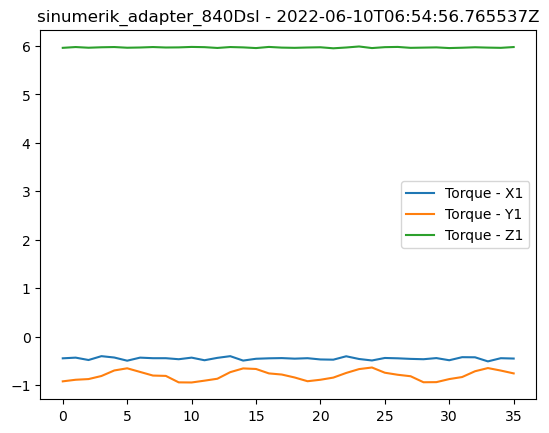

In [14]:
import matplotlib.pyplot as plt

occurence = 1206
for i in range(1,4):
    plt.plot(hf_data[occurence][attributes["Address"][i]], 
             label=f"{attributes['Name'][i]} - {attributes['Axis'][i]}")

plt.title(f"{machine['MachineName']} - {time_stamp}")
plt.legend()
plt.show()


In [16]:
hf_data[trial_run].rows()

AttributeError: 'DataFrame' object has no attribute 'rows'

In [15]:
hf_data_total = []

for trial_run in range(trial_runs):
    data_points = len(hf_data[trial_run])
    for data_point in range(data_points):
        hf_data_total.append(hf_data[trial_run].rows())
        
pd.dataFrame(hf_data_total)

KeyError: 51